In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# bibliotecas importadas

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

print("Configurações inicias!!")


Configurações inicias!!


In [2]:
df_orders = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_orders_dataset.csv')
df_order_items = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_order_items_dataset.csv')
df_order_reviews = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_order_reviews_dataset.csv')
df_customers = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_customers_dataset.csv')


print("Dados carregados")
print(f"Pedidos: {len(df_orders)}")
print(f"Itens: {len(df_order_items)}")
print(f"Reviews: {len(df_order_reviews)}")
print(f"Clientes: {len(df_customers)}")

Dados carregados
Pedidos: 99441
Itens: 112650
Reviews: 99224
Clientes: 99441


In [3]:
# Converter data para datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# Criar colunas de mês, ano e dia da semana
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.month
df_orders['purchase_year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['purchase_day_of_week'] = df_orders['order_purchase_timestamp'].dt.dayofweek


print(df_orders[['order_purchase_timestamp', 'purchase_month', 'purchase_year','purchase_day_of_week']].head())

  order_purchase_timestamp  purchase_month  purchase_year  \
0      2017-10-02 10:56:33              10           2017   
1      2018-07-24 20:41:37               7           2018   
2      2018-08-08 08:38:49               8           2018   
3      2017-11-18 19:28:06              11           2017   
4      2018-02-13 21:18:39               2           2018   

   purchase_day_of_week  
0                     0  
1                     1  
2                     2  
3                     5  
4                     1  


In [4]:
# Agrupar vendas por mês
vendas_por_mes = df_orders.groupby('purchase_month').size().reset_index()
vendas_por_mes.columns = ['mes', 'total_pedidos']

print("=== VENDAS POR MÊS ===")
print(vendas_por_mes)

=== VENDAS POR MÊS ===
    mes  total_pedidos
0     1           8069
1     2           8508
2     3           9893
3     4           9343
4     5          10573
5     6           9412
6     7          10318
7     8          10843
8     9           4305
9    10           4959
10   11           7544
11   12           5674


C:\Users\Mateus Fernandes\AppData\Local\Temp\ipykernel_11696\1654203677.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mes', y='total_pedidos', data=vendas_por_mes, palette='viridis')


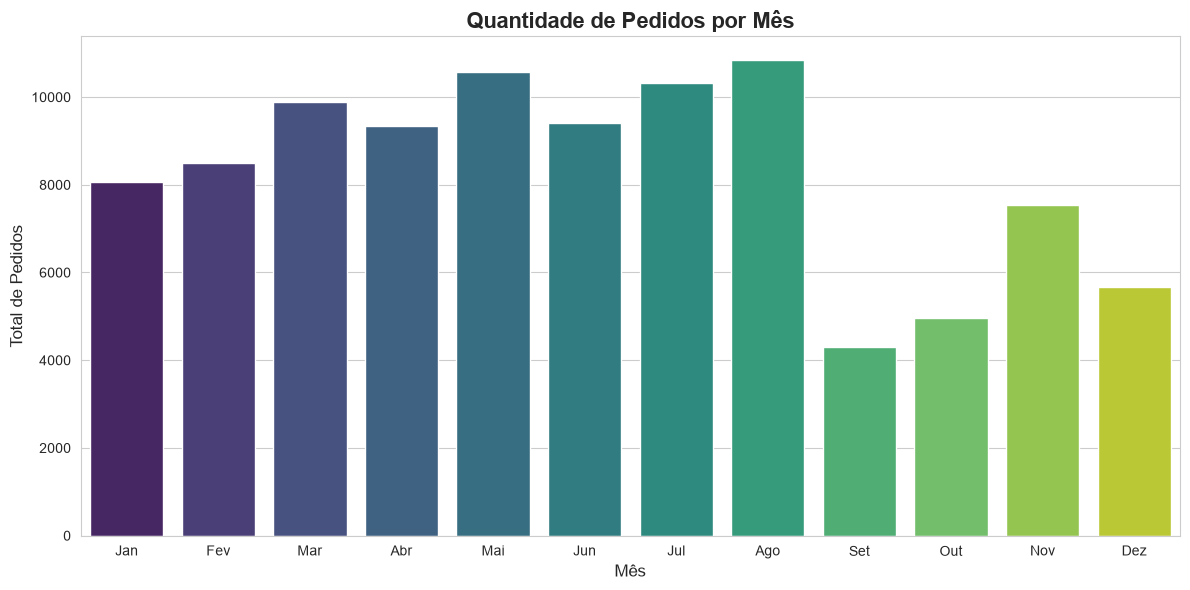

In [5]:
# Gráfico de vendas por mês
plt.figure(figsize=(12, 6))

sns.barplot(x='mes', y='total_pedidos', data=vendas_por_mes, palette='viridis')

plt.title('Quantidade de Pedidos por Mês', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total de Pedidos', fontsize=12)
plt.xticks(range(12), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                       'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

plt.tight_layout()
plt.savefig('assets/vendas_por_mes.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Identificar o mês com mais vendas
mes_mais_vendas = vendas_por_mes.loc[vendas_por_mes['total_pedidos'].idxmax()]
print(f"Mês com mais vendas: {mes_mais_vendas['mes']} - {mes_mais_vendas['total_pedidos']} pedidos")

Mês com mais vendas: 8 - 10843 pedidos


In [7]:
# Agrupar vendas por dia da semana
vendas_por_dia = df_orders.groupby('purchase_day_of_week').size().reset_index()
vendas_por_dia.columns = ['dia', 'total_pedidos']

# Mapear números para nomes dos dias
dias_semana = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 
               4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
vendas_por_dia['dia_nome'] = vendas_por_dia['dia'].map(dias_semana)

print("=== VENDAS POR DIA DA SEMANA ===")
print(vendas_por_dia)

=== VENDAS POR DIA DA SEMANA ===
   dia  total_pedidos dia_nome
0    0          16196  Segunda
1    1          15963    Terça
2    2          15552   Quarta
3    3          14761   Quinta
4    4          14122    Sexta
5    5          10887   Sábado
6    6          11960  Domingo


C:\Users\Mateus Fernandes\AppData\Local\Temp\ipykernel_11696\1973506669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dia_nome', y='total_pedidos', data=vendas_por_dia, palette='coolwarm')


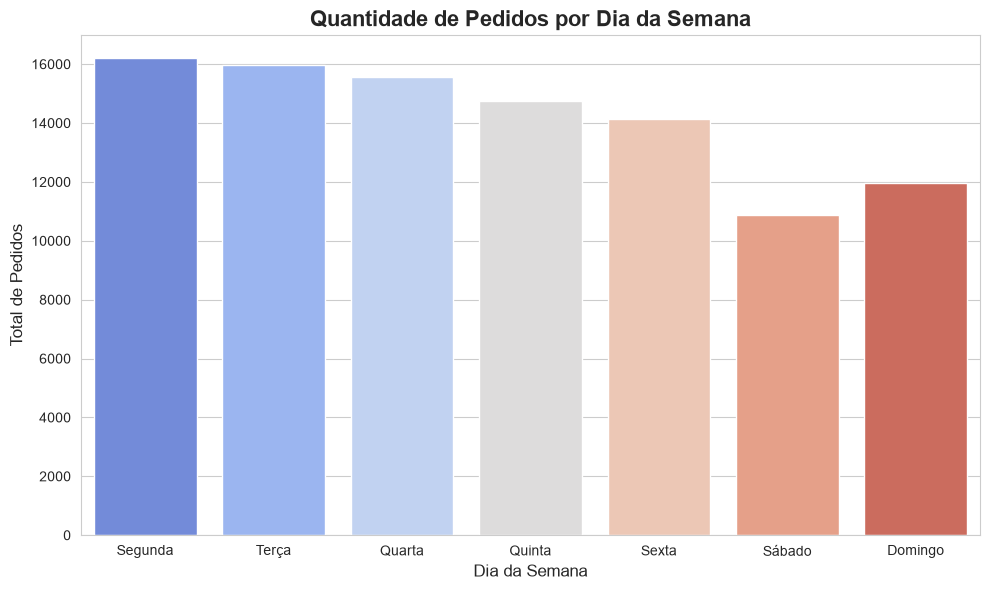

In [8]:
# Gráfico de vendas por dia da semana
plt.figure(figsize=(10, 6))

sns.barplot(x='dia_nome', y='total_pedidos', data=vendas_por_dia, palette='coolwarm')

plt.title('Quantidade de Pedidos por Dia da Semana', fontsize=16, fontweight='bold')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Total de Pedidos', fontsize=12)

plt.tight_layout()
plt.savefig('assets/vendas_por_dia_semana.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Juntar orders com customers e reviews
df_merged = df_orders.merge(df_customers, on='customer_id', how='inner')
df_merged = df_merged.merge(df_order_reviews, on='order_id', how='inner')

# Calcular nota média por estado
nota_por_estado = df_merged.groupby('customer_state')['review_score'].mean().reset_index()
nota_por_estado.columns = ['estado', 'nota_media']
nota_por_estado = nota_por_estado.sort_values('nota_media', ascending=False)

print("=== NOTA MÉDIA POR ESTADO ===")
print(nota_por_estado.head(10))

=== NOTA MÉDIA POR ESTADO ===
   estado  nota_media
3      AP    4.194030
2      AM    4.183673
17     PR    4.180032
25     SP    4.173951
10     MG    4.136172
22     RS    4.133321
11     MS    4.118785
19     RN    4.105809
12     MT    4.102990
26     TO    4.096774


C:\Users\Mateus Fernandes\AppData\Local\Temp\ipykernel_11696\10825537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nota_media', y='estado', data=nota_por_estado.head(10), palette='viridis')


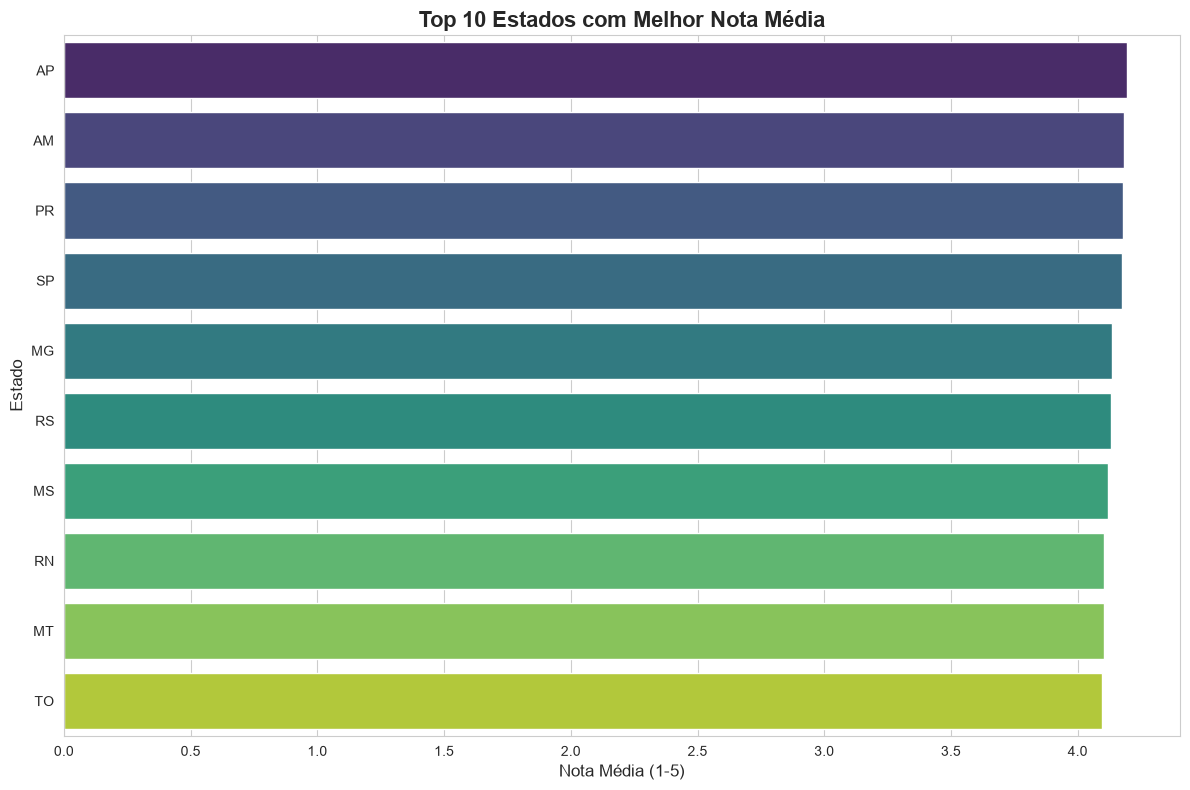

In [10]:
# Gráfico de nota média por estado
plt.figure(figsize=(12, 8))

sns.barplot(x='nota_media', y='estado', data=nota_por_estado.head(10), palette='viridis')

plt.title('Top 10 Estados com Melhor Nota Média', fontsize=16, fontweight='bold')
plt.xlabel('Nota Média (1-5)', fontsize=12)
plt.ylabel('Estado', fontsize=12)

plt.tight_layout()
plt.savefig('assets/nota_por_estado.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Criar coluna de ano-mês
df_orders['year_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

# Agrupar vendas por ano-mês
vendas_por_ano_mes = df_orders.groupby('year_month').size().reset_index()
vendas_por_ano_mes.columns = ['ano_mes', 'total_pedidos']

# Converter para string para plotar
vendas_por_ano_mes['ano_mes_str'] = vendas_por_ano_mes['ano_mes'].astype(str)

print("=== VENDAS POR MÊS (SÉRIE TEMPORAL) ===")
print(vendas_por_ano_mes.head(10))

=== VENDAS POR MÊS (SÉRIE TEMPORAL) ===
   ano_mes  total_pedidos ano_mes_str
0  2016-09              4     2016-09
1  2016-10            324     2016-10
2  2016-12              1     2016-12
3  2017-01            800     2017-01
4  2017-02           1780     2017-02
5  2017-03           2682     2017-03
6  2017-04           2404     2017-04
7  2017-05           3700     2017-05
8  2017-06           3245     2017-06
9  2017-07           4026     2017-07


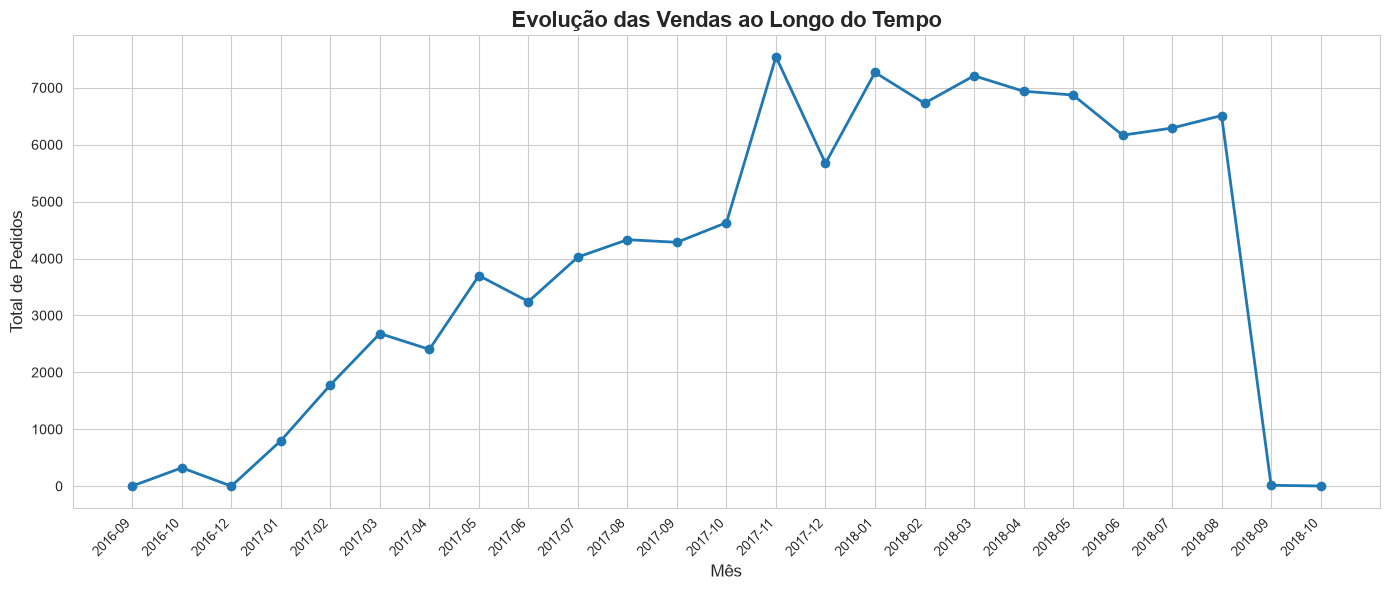

In [12]:
# Gráfico de linha - série temporal
plt.figure(figsize=(14, 6))

plt.plot(vendas_por_ano_mes['ano_mes_str'], vendas_por_ano_mes['total_pedidos'], 
         marker='o', linewidth=2, markersize=6)

plt.title('Evolução das Vendas ao Longo do Tempo', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total de Pedidos', fontsize=12)

# Rotacionar os rótulos do eixo X para não sobrepor
plt.xticks(rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('assets/evolucao_vendas_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

##  Análise de Sazonalidade - Dia 7

### 1. Vendas por Mês
- **Meses com mais vendas:** Maio (10.573), Julho (10.318) e Agosto (10.843)
- **Meses com menos vendas:** Setembro (4.305) e Outubro (4.959)
- **Padrão:** Vendas caem drasticamente em Setembro/Outubro

### 2. Vendas por Dia da Semana
- **Dia com mais vendas:** Segunda-feira (16.196 pedidos)
- **Dia com menos vendas:** Sábado (10.887 pedidos)
- **Padrão:** Início da semana concentra ~60% das vendas

### 3. Nota Média por Estado
- **Estado com melhor nota:** AP (Amapá) - 4.19
- **Estado com pior nota:** (verificar o último)
- **Padrão:** Estados do Norte/Nordeste têm melhores avaliações

### 4. Recomendações de Negócio
- **Campanhas:** Focar em Maio, Julho e Agosto
- **Estoque:** Aumentar estoque para início da semana
- **Atendimento:** Melhorar atendimento em estados com nota baixa
- **Marketing:** Campanhas específicas para Setembro/Outubro